# EE 446 TinyML — Lab 3  
## Quantization of a DNN Using the UCI Human Activity Recognition Dataset

This is the **student version** of the lab notebook.

Complete all code cells marked with **TODO**.  
Use clear variable names and keep the overall notebook structure unchanged.


## 1. Environment Setup

Use the `Python (tinyml-arduino)` Jupyter kernel for this notebook.
All required packages are expected to be preinstalled in the course environment.


In [1]:
import sys
#!{sys.executable} -m pip install -q "tensorflow==2.15.1" "tensorflow-model-optimization==0.8.0" "scikit-learn==1.4.2" "pandas==2.2.2" "matplotlib==3.8.4"


## 2. Imports and Reproducibility


In [7]:
import os
import zipfile
import pathlib
import random
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf
import tensorflow_model_optimization as tfmot

from sklearn.metrics import accuracy_score, classification_report, confusion_matrix, ConfusionMatrixDisplay
from tensorflow import keras
from tensorflow.keras import layers, models

SEED = 42
random.seed(SEED)
np.random.seed(SEED)
tf.random.set_seed(SEED)

print("TensorFlow version:", tf.__version__)
print("TF-MOT version:", tfmot.__version__)


2026-04-19 19:39:25.390558: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-19 19:39:25.811323: E tensorflow/compiler/xla/stream_executor/cuda/cuda_dnn.cc:9342] Unable to register cuDNN factory: Attempting to register factory for plugin cuDNN when one has already been registered
2026-04-19 19:39:25.811424: E tensorflow/compiler/xla/stream_executor/cuda/cuda_fft.cc:609] Unable to register cuFFT factory: Attempting to register factory for plugin cuFFT when one has already been registered
2026-04-19 19:39:25.814150: E tensorflow/compiler/xla/stream_executor/cuda/cuda_blas.cc:1518] Unable to register cuBLAS factory: Attempting to register factory for plugin cuBLAS when one has already been registered
2026-04-19 19:39:26.031103: I tensorflow/tsl/cuda/cudart_stub.cc:28] Could not find cuda drivers on your machine, GPU will not be used.
2026-04-19 19:39:26.033621: I tensorflow/core/platform/cpu_feature_guard.cc:182] This Tens

TensorFlow version: 2.14.1
TF-MOT version: 0.8.0


## 3. Download and Extract the UCI HAR Dataset

The original dataset contains:
- **561 numerical features** extracted from smartphone sensor signals
- **6 activity classes**
- predefined **training** and **test** splits

The code below downloads and extracts the dataset if it is not already present.


In [2]:
dataset_url = "https://archive.ics.uci.edu/ml/machine-learning-databases/00240/UCI%20HAR%20Dataset.zip"
zip_path = "uci_har_dataset.zip"
extract_dir = "."

if not os.path.exists("UCI HAR Dataset"):
    !wget -q "{dataset_url}" -O "{zip_path}"
    with zipfile.ZipFile(zip_path, "r") as zf:
        zf.extractall(extract_dir)
    print("Dataset downloaded and extracted.")
else:
    print("Dataset directory already exists.")


Dataset downloaded and extracted.


In [5]:
%pwd

'/mnt/c/Users/cliff/Downloads/tinyml_env_setup_package/tinyml_env_setup_package'

## 4. Load the Data


In [22]:
import pandas as pd

def load_har_data(root_dir="UCI HAR Dataset"):
    # TODO:
    # 1. Load X_train from train/X_train.txt
    # 2. Load y_train from train/y_train.txt
    # 3. Load X_test from test/X_test.txt
    # 4. Load y_test from test/y_test.txt
    # 5. Convert the labels to zero-based class indices by subtracting 1
    path = '/mnt/c/Users/cliff/Downloads/tinyml_env_setup_package/tinyml_env_setup_package'

    X_train = pd.read_csv(path + "/UCI HAR Dataset/train/X_train.txt", sep = '\s+', header = None).values
    X_test = pd.read_csv(path + "/UCI HAR Dataset/test/X_test.txt", sep = '\s+', header = None).values
    y_train = pd.read_csv(path + "/UCI HAR Dataset/train/y_train.txt", sep = '\s+', header = None).values.flatten()
    y_test = pd.read_csv(path + "/UCI HAR Dataset/test/y_test.txt", sep = '\s+', header = None).values.flatten()

    y_test -= 1
    y_train-= 1

    return X_train, y_train, X_test, y_test
    

X_train, y_train, X_test, y_test = load_har_data()

class_names = [
    "WALKING",
    "WALKING_UPSTAIRS",
    "WALKING_DOWNSTAIRS",
    "SITTING",
    "STANDING",
    "LAYING"
]

num_classes = len(class_names)

num_features = X_train.shape[1]
# TODO: define num_features and num_classes
# <-- Enter your code here <--#


## 5. Quick Inspection


In [46]:
# TODO:
# Create a small summary table showing the class index, class name, and number of training samples.

unique, counts = np.unique(y_train, return_counts=True)
counts_dict = dict(zip(unique, counts))

# 2. Create the summary data
summary_data = []
for i, name in enumerate(class_names):
    summary_data.append({
        "Class Index": i,
        "Class Name": name,
        "Training Samples": counts_dict.get(i, 0)
    })

# 3. Create and display the DataFrame
df_summary = pd.DataFrame(summary_data)

print("Dataset Summary:")
print(df_summary.to_string(index=False))
# <-- Enter your code here <--#


Dataset Summary:
 Class Index         Class Name  Training Samples
           0            WALKING              1226
           1   WALKING_UPSTAIRS              1073
           2 WALKING_DOWNSTAIRS               986
           3            SITTING              1286
           4           STANDING              1374
           5             LAYING              1407


## 6. Train a Baseline DNN

We will use a compact dense neural network that is appropriate for a numerical-feature TinyML-style workflow.

### Architecture
- Input: 561 features
- Dense(256, ReLU)
- Dense(128, ReLU)
- Dense(64, ReLU)
- Dense(6, Softmax)


In [15]:
def build_baseline_model(input_dim, num_classes):
    # TODO:
    # input = Input(shape = input_dim, )

    model = models.Sequential([
        layers.Input(shape = (input_dim,)),
        layers.Dense(256, activation = 'relu'),
        layers.Dense(128, activation = 'relu'),
        layers.Dense(64, activation = 'relu'),
        layers.Dense(num_classes, activation = 'softmax')
    ])

    lr_val = .001

    optim = tf.keras.optimizers.Adam(learning_rate = lr_val)
    
    
    model.compile(
        optimizer = optim,
        loss = 'sparse_categorical_crossentropy',
        metrics = ['accuracy']
        


    )
    return model
    # Build and compile a DNN with the following architecture:
    # Input -> Dense(256, relu) -> Dense(128, relu) -> Dense(64, relu) -> Dense(num_classes, softmax)
    # Use Adam with learning rate 1e-3.
    # Use sparse_categorical_crossentropy as the loss.
    # Track accuracy as a metric.


baseline_model = build_baseline_model(num_features, num_classes)
baseline_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 dense_4 (Dense)             (None, 256)               143872    
                                                                 
 dense_5 (Dense)             (None, 128)               32896     
                                                                 
 dense_6 (Dense)             (None, 64)                8256      
                                                                 
 dense_7 (Dense)             (None, 6)                 390       
                                                                 
Total params: 185414 (724.27 KB)
Trainable params: 185414 (724.27 KB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


### Train the Baseline Model


In [16]:
callbacks = [
    keras.callbacks.EarlyStopping(
        monitor="val_accuracy",
        patience=5,
        restore_best_weights=True
    )
]

hist = baseline_model.fit(
    X_train,
    y_train,
    validation_split = 0.2,
    epochs = 40,
    batch_size = 64,
    callbacks = callbacks
)
# TODO:
# Train the baseline model using:
# - validation_split=0.2
# - epochs=40
# - batch_size=64
# - callbacks=callbacks

# <-- Enter your code here <--#


Epoch 1/40
92/92 [==============================] - 1s 8ms/step - loss: 0.4751 - accuracy: 0.8067 - val_loss: 0.2226 - val_accuracy: 0.9218
Epoch 2/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1763 - accuracy: 0.9340 - val_loss: 0.1587 - val_accuracy: 0.9293
Epoch 3/40
92/92 [==============================] - 1s 6ms/step - loss: 0.1141 - accuracy: 0.9551 - val_loss: 0.4137 - val_accuracy: 0.8831
Epoch 4/40
92/92 [==============================] - 1s 10ms/step - loss: 0.0973 - accuracy: 0.9595 - val_loss: 0.1779 - val_accuracy: 0.9347
Epoch 5/40
92/92 [==============================] - 1s 9ms/step - loss: 0.0885 - accuracy: 0.9648 - val_loss: 0.2308 - val_accuracy: 0.9184
Epoch 6/40
92/92 [==============================] - 1s 8ms/step - loss: 0.0675 - accuracy: 0.9742 - val_loss: 0.1861 - val_accuracy: 0.9347
Epoch 7/40
92/92 [==============================] - -2s -17675us/step - loss: 0.0767 - accuracy: 0.9711 - val_loss: 0.1192 - val_accuracy: 0.9511
Epoch 8/40
92

### Training Curves


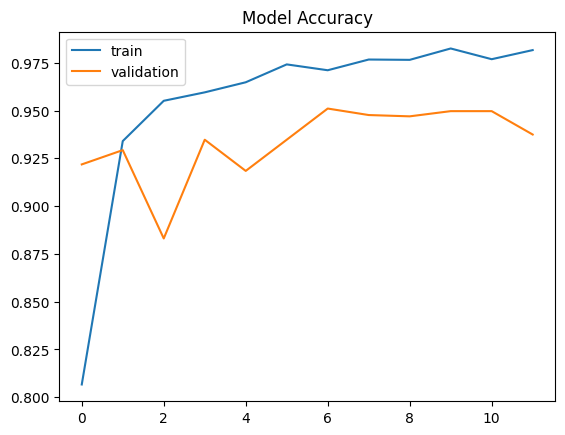

In [17]:

# Plot the accuracy over time
plt.plot(hist.history['accuracy'], label='train')
plt.plot(hist.history['val_accuracy'], label='validation')
plt.title('Model Accuracy')
plt.legend()
plt.show()

## 7. Evaluate the Baseline Keras Model


93/93 [==============================] - 0s 2ms/step - loss: 0.1848 - accuracy: 0.9362
test accuracy : 0.9362063407897949
              precision    recall  f1-score   support

           0       0.96      0.97      0.96       496
           1       0.96      0.90      0.93       471
           2       0.91      0.95      0.93       420
           3       0.94      0.88      0.91       491
           4       0.87      0.94      0.91       532
           5       1.00      0.96      0.98       537

    accuracy                           0.94      2947
   macro avg       0.94      0.94      0.94      2947
weighted avg       0.94      0.94      0.94      2947



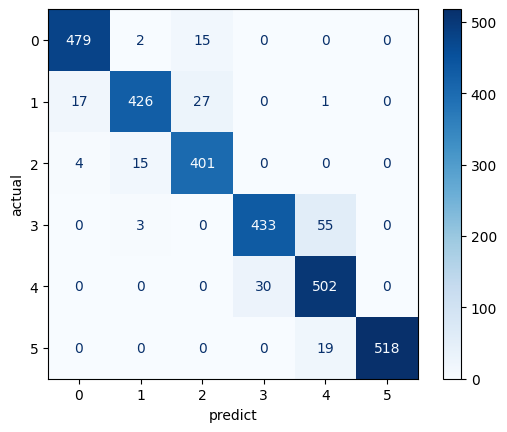

In [18]:
# TODO:
# 1. Obtain predicted probabilities on X_test
# 2. Convert them to class predictions using argmax
# 3. Compute test accuracy
# 4. Print the classification report
# 5. Plot the confusion matrix
predicted = baseline_model.predict(X_test)

predictions = np.argmax(predicted, axis = 1)


res = baseline_model.evaluate(X_test, y_test)
print(f"test accuracy : {res[1]}")

print(classification_report(y_test,predictions))

# cm = confusion_matrix(y_test, predictions)
ConfusionMatrixDisplay.from_predictions(y_test, predictions, cmap = plt.cm.Blues)
plt.xlabel('predict')
plt.ylabel('actual')
plt.show()
# <-- Enter your code here <--#


## 8. TensorFlow Lite Utilities

The following helper functions are used to:
- convert Keras models to TensorFlow Lite,
- evaluate TensorFlow Lite models on the test set, and
- measure model file size.


In [24]:
def save_binary_model(model_content, filename):
    with open(filename, "wb") as f:
        f.write(model_content)
    return os.path.getsize(filename) / 1024.0  # KB

def representative_dataset_gen():
    # TODO:
    # Yield 300 representative samples from X_train as float32 tensors.
    # Each yielded item should be in the form: [sample]
    for sample in X_train[:300]:
        yield [sample[np.newaxis, ...].astype(np.float32)]

def evaluate_tflite_model(tflite_model, X, y_true):
    interpreter = tf.lite.Interpreter(model_content=tflite_model)
    interpreter.allocate_tensors()

    input_details = interpreter.get_input_details()[0]
    output_details = interpreter.get_output_details()[0]

    input_scale, input_zero_point = input_details["quantization"]
    output_scale, output_zero_point = output_details["quantization"]

    input_dtype = input_details["dtype"]
    output_dtype = output_details["dtype"]
    
    y_pred = []

    for i in range(len(X)):
        input_data = X[i:i+1].astype(np.float32)

        if input_dtype == np.int8:
            input_data = np.round(input_data / input_scale + input_zero_point).astype(np.int8)
        elif input_dtype == np.uint8:
            input_data = np.round(input_data / input_scale + input_zero_point).astype(np.uint8)
        else:
            input_data = input_data.astype(input_dtype)
        
        interpreter.set_tensor(input_details["index"], input_data)
        interpreter.invoke()

        output = interpreter.get_tensor(output_details["index"])

        if output_dtype in (np.int8, np.uint8) and output_scale != 0:
            output = (output.astype(np.float32) - output_zero_point) * output_scale

        y_pred.append(np.argmax(output, axis=1)[0])

    y_pred = np.array(y_pred)
    acc = accuracy_score(y_true, y_pred)
    return acc, y_pred


def convert_to_tflite_fp32(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO: return the converted FP32 TensorFlow Lite model
    # <-- Enter your code here <--#
    tflitemodel = converter.convert()
    return tflitemodel

def convert_to_tflite_dynamic_range(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization and return the converted model.
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    tflitemodel = converter.convert()
    return tflitemodel
    
def convert_to_tflite_float16(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.target_spec.supported_ops = [tf.float16]
    tflitemodel = converter.convert()
    return tflitemodel


def convert_to_tflite_int8(model):
    converter = tf.lite.TFLiteConverter.from_keras_model(model)
    # TODO:
    # Apply default optimization
    converter.optimizations = [tf.lite.Optimize.DEFAULT]
    converter.representative_dataset = representative_dataset_gen
    converter.target_spec.supported_ops = [tf.lite.OpsSet.TFLITE_BUILTINS_INT8]
    # Attach representative_dataset_gen
    # Restrict to TFLITE_BUILTINS_INT8
    # Set inference_input_type and inference_output_type to tf.int8
    converter.inference_input_type = tf.int8
    converter.inference_output_type = tf.int8
    tflitemodel = converter.convert()
    return tflitemodel
    # Return the converted model

    # <-- Enter your code here <--#


## 9. Post-Training Quantization (PTQ)


In [25]:
# TODO:
# Convert the baseline model into:
# - FP32 TFLite
# - dynamic range TFLite
# - float16 TFLite
# - int8 TFLite

# Save each model to disk and record its size in KB.
# Evaluate each TFLite model on the test set.

tflite_fp32 = convert_to_tflite_fp32(baseline_model)
tflite_dynamic = convert_to_tflite_dynamic_range(baseline_model)
tflite_fp16 = convert_to_tflite_float16(baseline_model)
tflite_int8 = convert_to_tflite_int8(baseline_model)


size_fp32 = save_binary_model(tflite_fp32, "model_fp32.tflite")
size_dynamic = save_binary_model(tflite_dynamic, "model_dynamic.tflite")
size_fp16 = save_binary_model(tflite_fp16, "model_fp16.tflite")
size_int8 = save_binary_model(tflite_int8, "model_int8.tflite")


acc_fp32, _ = evaluate_tflite_model(tflite_fp32, X_test, y_test)
acc_dynamic, _ = evaluate_tflite_model(tflite_dynamic, X_test, y_test)
acc_fp16, _ = evaluate_tflite_model(tflite_fp16, X_test, y_test)
acc_int8, _ = evaluate_tflite_model(tflite_int8, X_test, y_test)


INFO:tensorflow:Assets written to: /tmp/tmpuw9a_tvw/assets


INFO:tensorflow:Assets written to: /tmp/tmpuw9a_tvw/assets
2026-04-19 19:47:24.240523: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 19:47:24.240592: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 19:47:24.240797: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpuw9a_tvw
2026-04-19 19:47:24.242014: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 19:47:24.242029: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpuw9a_tvw
2026-04-19 19:47:24.246260: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 19:47:24.296845: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpuw9a_tvw
2026-04-19 19:47:24.311033: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmp_1tpnmet/assets


INFO:tensorflow:Assets written to: /tmp/tmp_1tpnmet/assets
2026-04-19 19:47:25.555224: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 19:47:25.555288: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 19:47:25.555481: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmp_1tpnmet
2026-04-19 19:47:25.556881: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 19:47:25.556905: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmp_1tpnmet
2026-04-19 19:47:25.560652: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 19:47:25.609846: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmp_1tpnmet
2026-04-19 19:47:25.624489: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpvl5eo0dk/assets


INFO:tensorflow:Assets written to: /tmp/tmpvl5eo0dk/assets
2026-04-19 19:47:26.407267: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 19:47:26.407345: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 19:47:26.407537: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpvl5eo0dk
2026-04-19 19:47:26.408875: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 19:47:26.408892: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpvl5eo0dk
2026-04-19 19:47:26.412364: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2026-04-19 19:47:26.461382: I tensorflow/cc/saved_model/loader.cc:217] Running initialization op on SavedModel bundle at path: /tmp/tmpvl5eo0dk
2026-04-19 19:47:26.475395: I tensorflow/cc/saved_model/loader.cc:316] SavedModel

INFO:tensorflow:Assets written to: /tmp/tmpo9o_vif0/assets


INFO:tensorflow:Assets written to: /tmp/tmpo9o_vif0/assets
/home/cliffpm/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-19 19:47:27.247710: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 19:47:27.247779: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 19:47:27.248002: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpo9o_vif0
2026-04-19 19:47:27.249177: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 19:47:27.249203: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpo9o_vif0
2026-04-19 19:47:27.252043: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2

## 10. PTQ Comparison: Accuracy and Model Size


In [43]:
# TODO:
# Create a comparison DataFrame containing:
# Model Family, Format, Test Accuracy, Model Size (KB)
import seaborn as sns


data = {
    "Model Family": ["Baseline", "Baseline", "Baseline", "Baseline"],
    "Format": ["FP32", "Dynamic Range", "Float16", "Int8"],
    "Test Accuracy": [acc_fp32, acc_dynamic, acc_fp16, acc_int8],
    "Model Size (KB)": [size_fp32, size_dynamic, size_fp16, size_int8]
}
df_comparison = pd.DataFrame(data)

df_comparison.head()

,Model Family,Format,Test Accuracy,Model Size (KB)
0,Baseline,FP32,0.936206,726.750000
1,Baseline,Dynamic Range,0.936546,186.140625
2,Baseline,Float16,0.936546,186.140625
3,Baseline,Int8,0.935867,185.351562


/tmp/ipykernel_715/1842692540.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparison, x="Format", y="Model Size (KB)", ax=ax[0], palette="viridis")
/tmp/ipykernel_715/1842692540.py:10: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(data=df_comparison, x="Format", y="Test Accuracy", ax=ax[1], palette="magma")


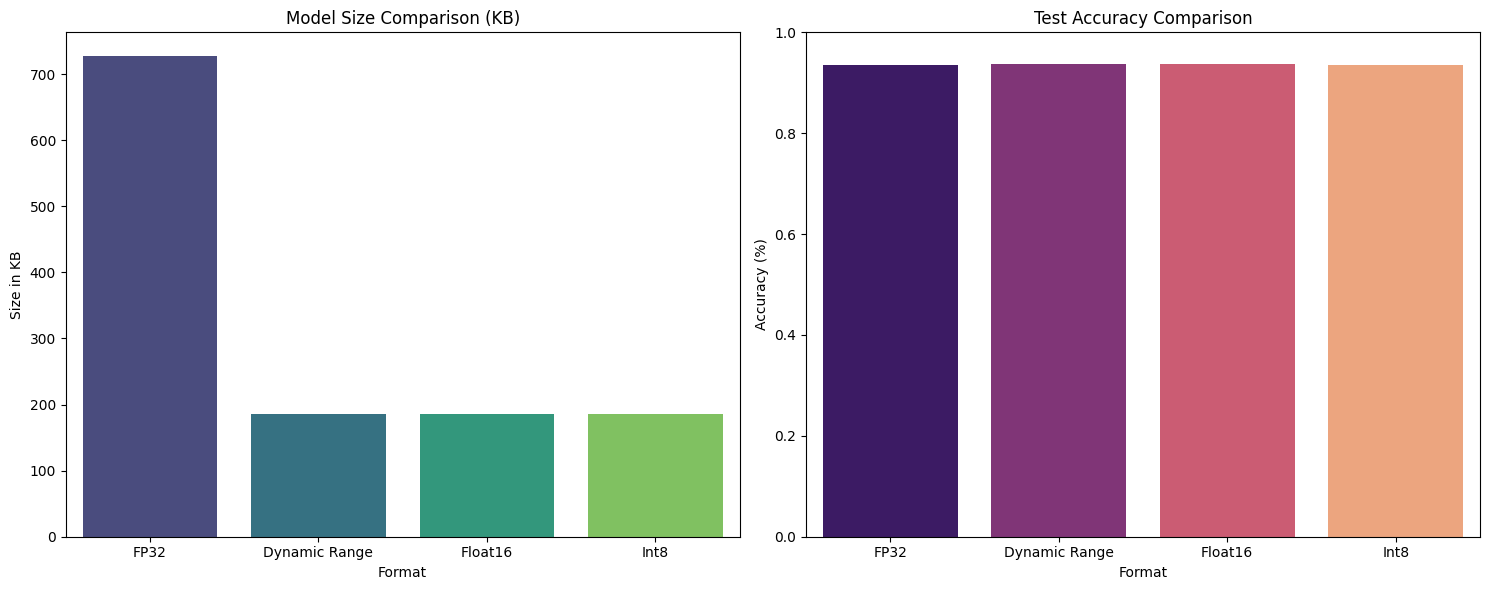

In [29]:
# TODO:
# Create one bar plot for model size and another for test accuracy.

fig, ax = plt.subplots(1, 2, figsize=(15, 6))

sns.barplot(data=df_comparison, x="Format", y="Model Size (KB)", ax=ax[0], palette="viridis")
ax[0].set_title("Model Size Comparison (KB)")
ax[0].set_ylabel("Size in KB")

sns.barplot(data=df_comparison, x="Format", y="Test Accuracy", ax=ax[1], palette="magma")
ax[1].set_title("Test Accuracy Comparison")
ax[1].set_ylabel("Accuracy (%)")
ax[1].set_ylim(0, 1.0)

plt.tight_layout()
plt.show()


### Confusion Matrix for the PTQ Int8 Model


<Figure size 1000x800 with 0 Axes>

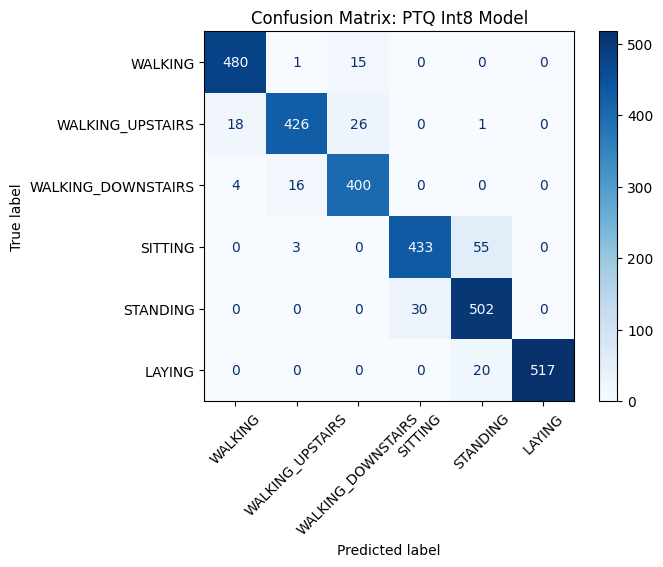

In [31]:
# TODO:
# Plot the confusion matrix for the PTQ int8 model.
# Print the classification report for the PTQ int8 model.
acc_int8, y_pred_int8 = evaluate_tflite_model(tflite_int8, X_test, y_test)


cm = confusion_matrix(y_test, y_pred_int8)
plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=class_names)
disp.plot(cmap=plt.cm.Blues, xticks_rotation=45)
plt.title("Confusion Matrix: PTQ Int8 Model")
plt.show()


In [32]:
print("Classification Report (Int8 Model):")
print(classification_report(y_test, y_pred_int8, target_names=class_names))

Classification Report (Int8 Model):
                    precision    recall  f1-score   support

           WALKING       0.96      0.97      0.96       496
  WALKING_UPSTAIRS       0.96      0.90      0.93       471
WALKING_DOWNSTAIRS       0.91      0.95      0.93       420
           SITTING       0.94      0.88      0.91       491
          STANDING       0.87      0.94      0.90       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.94      2947
         macro avg       0.94      0.94      0.94      2947
      weighted avg       0.94      0.94      0.94      2947



## 11. Quantization-Aware Training (QAT)

QAT simulates quantization effects during training so that the final model is usually more robust after conversion to int8.


In [34]:
# TODO:
# Create a QAT model from the trained baseline model using TF-MOT.
# Compile it with Adam(1e-4), sparse_categorical_crossentropy, and accuracy.

qat_model = tfmot.quantization.keras.quantize_model(baseline_model)


qat_model.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

qat_model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 quantize_layer (QuantizeLa  (None, 561)               3         
 yer)                                                            
                                                                 
 quant_dense_4 (QuantizeWra  (None, 256)               143877    
 pperV2)                                                         
                                                                 
 quant_dense_5 (QuantizeWra  (None, 128)               32901     
 pperV2)                                                         
                                                                 
 quant_dense_6 (QuantizeWra  (None, 64)                8261      
 pperV2)                                                         
                                                                 
 quant_dense_7 (QuantizeWra  (None, 6)                

### Fine-Tune the QAT Model


In [35]:
# TODO:
# Fine-tune the QAT model for 8 epochs using validation_split=0.2 and batch_size=64.

history_qat = qat_model.fit(
    X_train, 
    y_train, 
    epochs=8, 
    validation_split=0.2, 
    batch_size=64
)


Epoch 1/8
92/92 [==============================] - 3s 10ms/step - loss: 0.0730 - accuracy: 0.9813 - val_loss: 0.1221 - val_accuracy: 0.9511
Epoch 2/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0434 - accuracy: 0.9871 - val_loss: 0.1212 - val_accuracy: 0.9511
Epoch 3/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0403 - accuracy: 0.9867 - val_loss: 0.1303 - val_accuracy: 0.9538
Epoch 4/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0365 - accuracy: 0.9878 - val_loss: 0.1245 - val_accuracy: 0.9504
Epoch 5/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0346 - accuracy: 0.9888 - val_loss: 0.1501 - val_accuracy: 0.9477
Epoch 6/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0336 - accuracy: 0.9881 - val_loss: 0.1435 - val_accuracy: 0.9524
Epoch 7/8
92/92 [==============================] - 1s 9ms/step - loss: 0.0341 - accuracy: 0.9884 - val_loss: 0.1309 - val_accuracy: 0.9538
Epoch 8/8
92/92 [=========

### Evaluate the QAT Keras Model


In [36]:
loss_qat, acc_qat = qat_model.evaluate(X_test, y_test, verbose=0)

y_pred_qat_probs = qat_model.predict(X_test)
y_pred_qat = np.argmax(y_pred_qat_probs, axis=1)

print(f"QAT Keras Model Test Accuracy: {acc_qat:.4f}")
print("\nClassification Report (QAT Keras Model):")
print(classification_report(y_test, y_pred_qat, target_names=class_names))

93/93 [==============================] - 0s 3ms/step
QAT Keras Model Test Accuracy: 0.9325

Classification Report (QAT Keras Model):
                    precision    recall  f1-score   support

           WALKING       0.92      0.96      0.94       496
  WALKING_UPSTAIRS       0.95      0.90      0.93       471
WALKING_DOWNSTAIRS       0.93      0.94      0.94       420
           SITTING       0.96      0.86      0.91       491
          STANDING       0.85      0.97      0.91       532
            LAYING       1.00      0.96      0.98       537

          accuracy                           0.93      2947
         macro avg       0.94      0.93      0.93      2947
      weighted avg       0.94      0.93      0.93      2947



### Convert the QAT Model to Int8 TensorFlow Lite


In [39]:
# TODO:
# Convert the QAT model to int8 TensorFlow Lite.
# Save the model, compute its size, and evaluate it on the test set.

tflite_int8_qat = convert_to_tflite_int8(qat_model)

size_qat = save_binary_model(tflite_int8_qat, "model_qt.tflite")

acc_qat, y_pred_qat = evaluate_tflite_model(tflite_int8_qat, X_test, y_test)


INFO:tensorflow:Assets written to: /tmp/tmpysepjgyg/assets


INFO:tensorflow:Assets written to: /tmp/tmpysepjgyg/assets
/home/cliffpm/ai/projects/tinyml-arduino/lib/python3.11/site-packages/tensorflow/lite/python/convert.py:947: UserWarning: Statistics for quantized inputs were expected, but not specified; continuing anyway.
  warnings.warn(
2026-04-19 20:08:20.833906: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:378] Ignored output_format.
2026-04-19 20:08:20.833973: W tensorflow/compiler/mlir/lite/python/tf_tfl_flatbuffer_helpers.cc:381] Ignored drop_control_dependency.
2026-04-19 20:08:20.834180: I tensorflow/cc/saved_model/reader.cc:83] Reading SavedModel from: /tmp/tmpysepjgyg
2026-04-19 20:08:20.837872: I tensorflow/cc/saved_model/reader.cc:51] Reading meta graph with tags { serve }
2026-04-19 20:08:20.837890: I tensorflow/cc/saved_model/reader.cc:146] Reading SavedModel debug info (if present) from: /tmp/tmpysepjgyg
2026-04-19 20:08:20.849638: I tensorflow/cc/saved_model/loader.cc:233] Restoring SavedModel bundle.
2

## 12. PTQ Int8 vs QAT Int8


In [44]:
# TODO:
# Create a DataFrame comparing PTQ int8 and QAT int8:
# Model, Test Accuracy, Model Size (KB)

results = pd.DataFrame({
    "Format": ["FP32", "Dynamic", "FP16", "Int8 (PTQ)", "Int8 (QAT)"],
    "Accuracy": [acc_fp32, acc_dynamic, acc_fp16, acc_int8, acc_qat],
    "Size (KB)": [size_fp32, size_dynamic, size_fp16, size_int8, size_qat]
})

results.head()

,Format,Accuracy,Size (KB)
0,FP32,0.936206,726.750000
1,Dynamic,0.936546,186.140625
2,FP16,0.936546,186.140625
3,Int8 (PTQ),0.935867,185.351562
4,Int8 (QAT),0.932474,185.773438


<Figure size 1000x800 with 0 Axes>

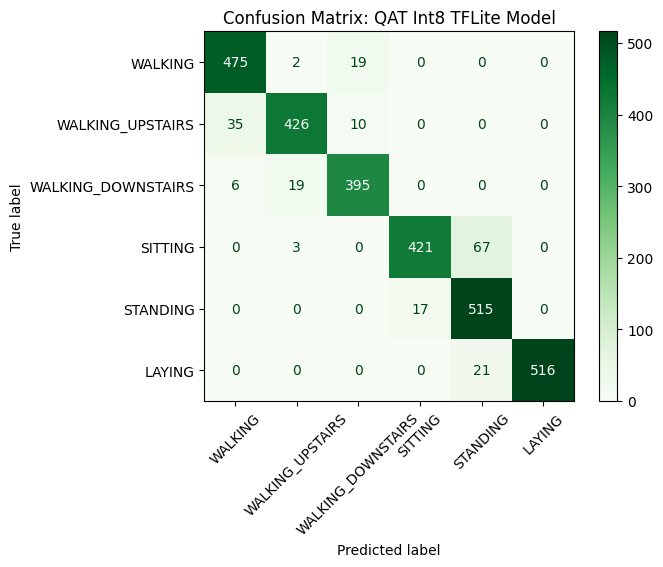

In [42]:
# TODO:
# Plot the confusion matrix for the QAT int8 model.

cm_qat = confusion_matrix(y_test, y_pred_qat)

plt.figure(figsize=(10, 8))
disp = ConfusionMatrixDisplay(confusion_matrix=cm_qat, display_labels=class_names)

disp.plot(cmap=plt.cm.Greens, xticks_rotation=45)

plt.title("Confusion Matrix: QAT Int8 TFLite Model")
plt.show()


## 13. Summary Questions

Write short answers to the following:
1. Which quantization method gave the smallest model size? PTQ and QAT for int8 gave the smallest model size since it is the method that reduces the representation to the least amount of bits for a larger number of parameters.
2. Which quantization method gave the best accuracy among the TensorFlow Lite models ? Float 16 and Dynamic Range gave the best accuracy among all other TF lite models, though the accuracies are so close that it is negligible in practice.

3. Did QAT improve the final int8 model compared with PTQ int8? Typically QAT almost always improve accuracy over PTQ, but in my case PTQ actually was slightly higher by a very small amount.
4. Why is this dataset a good fit for a DNN-based TinyML workflow? This dataset is a good fit because the context of the dataset for activity recognition is a good use case for wearable devices.
6. If you were deploying this model on a resource-constrained device, which version would you choose and why? I would choose the QAT int8 TFLite version since the size fits typical limited flash storage for standard microcontrollers, and int8 would allow faster computation processing, which is important in the context of real time devices / electronics.


## 14. Submission Requirements

Submit the following:
- your completed notebook,
- the generated `.tflite` files,
- screenshots or output cells showing the final comparison table,
- confusion matrices for the baseline model and the final int8 model you want to highlight,
- and short written observations answering the summary questions.

Make sure your notebook runs from top to bottom without errors.
